# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


In [8]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Sampling techniques
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# XGBoost
from xgboost import XGBClassifier

# Metrics
from sklearn import metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Observations

The following libraries were imported for:

- Data manipulation and analysis (NumPy, Pandas)
- Data visualization (Matplotlib, Seaborn)
- Data preprocessing and sampling (SMOTE, RandomUnderSampler)
- Model building (Decision Tree, Random Forest, Bagging, AdaBoost, Gradient Boosting, XGBoost)
- Hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
- Model evaluation (Accuracy, Precision, Recall, F1-score, ROC-AUC)

# **Loading the dataset**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

visa = pd.read_csv("/content/drive/MyDrive/AIML-UTA-PY/EasyVisa.csv")
data = visa.copy()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Overview of the Dataset**

In [13]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Observation**
The dataset loads successfully and displays the first 5 rows.

In [14]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


**Observation**
The dataset loads successfully and displays the last 5 rows.

In [27]:
# Basic structure of the dataset
print("Shape:", data.shape)

# Data types and non-null counts
data.info()

Shape: (25480, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [28]:
# Missing value check
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [29]:
# Duplicate row check
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [30]:
# Unique values in each column
print("Unique Values:")
print(data.nunique())

Unique Values:
case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64


In [31]:
# Target variable distribution
print("Case Status Distribution:")
print(data["case_status"].value_counts())

print("\nCase Status Percentage:")
print(round(data["case_status"].value_counts(normalize=True) * 100, 2))

Case Status Distribution:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Case Status Percentage:
case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64


In [32]:
# Summary statistics
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Check negative values in no_of_employees
neg_count = (data["no_of_employees"] < 0).sum()
print("Negative no_of_employees rows:", neg_count)

Negative no_of_employees rows: 33


In [34]:
# Summary statistics
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Correct invalid employee counts
data["no_of_employees"] = data["no_of_employees"].abs()

# Verify correction
print(
    "Negative no_of_employees rows after correction:",
    (data["no_of_employees"] < 0).sum()
)

Negative no_of_employees rows after correction: 0




## Overview of the Dataset

### Overview

- The dataset contains **25,480 records and 12 variables**.
- The target variable is **case_status**, which indicates whether a visa application was **Certified** or **Denied**.
- The dataset consists of **9 categorical variables** and **3 numerical variables**.
- All variables contain **25,480 non-null values**, indicating that there are **no missing values** in the dataset.
- No duplicate records were found in the dataset.
- The variable **case_id** contains **25,480 unique values**, confirming that each visa application has a unique identifier.
- Approximately **66.79%** of visa applications were Certified, while **33.21%** were Denied, indicating a moderate class imbalance.
- The dataset appears clean overall and suitable for exploratory data analysis and predictive modeling.

### Sanity Checks

- Verified dataset dimensions using `shape()`.
- Reviewed data types and non-null counts using `info()`.
- Checked for missing values across all variables and found none.
- Checked for duplicate records and found 0 duplicates.
- Verified the target variable classes and their distribution.
- Checked the number of unique values in each variable.
- Identified 33 records with negative values in `no_of_employees`, which are not logically valid and require correction before model building.

### Observations from Summary Statistics

- The average employer size is approximately **5,667 employees**, although there is substantial variation across employers.
- The oldest company in the dataset was established in **1800**, while the newest companies were established in **2016**.
- The median prevailing wage is approximately **$70,308**, with wages ranging from **$2.14** to over **$319,000**, indicating considerable variability.
- The variables **no_of_employees** and **prevailing_wage** appear to contain extreme values and will be examined further during exploratory data analysis.
- A small number of invalid negative employee counts were detected and corrected during data preprocessing.

### Implications for Further Analysis

- The variable **case_id** serves as a unique identifier and will be removed during data preprocessing as it does not contribute to prediction.
- Since no missing values are present in the dataset, missing value imputation will not be required.
- The variable **no_of_employees** contained 33 invalid negative values, which were corrected during data preprocessing.
- Numerical variables such as **prevailing_wage**, **no_of_employees**, and **yr_of_estab** will be further examined for distribution, skewness, and potential outliers.
- Categorical variables such as **continent**, **education_of_employee**, **has_job_experience**, **region_of_employment**, and **unit_of_wage** may influence visa certification outcomes and will be explored in greater detail during EDA.
- The moderate class imbalance observed in the target variable suggests that model performance should be evaluated using metrics such as Precision, Recall, and F1-score, in addition to Accuracy.
- To assess the impact of class imbalance, models will be developed using the original data, oversampled data (SMOTE), and undersampled data.

### Business Insight

The dataset contains a combination of applicant-related and employer-related attributes that can help identify the factors influencing visa certification decisions. By analyzing these variables and building predictive models, EasyVisa can streamline the visa screening process, prioritize applications with a higher likelihood of approval, and improve overall decision-making efficiency.

# **Exploratory Data Analysis (EDA)**

In [36]:
data.describe(include="all")

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480.000000,25480.000000,25480,25480.000000,25480,25480,25480
unique,25480,6,4,2,2,NaN,NaN,5,NaN,4,2,2
top,EZYV25480,Asia,Bachelor's,Y,N,NaN,NaN,Northeast,NaN,Year,Y,Certified
freq,1,16861,10234,14802,22525,NaN,NaN,7195,NaN,22962,22773,17018
mean,NaN,NaN,NaN,NaN,NaN,5667.089207,1979.409929,NaN,74455.814592,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22877.917453,42.366929,NaN,52815.942327,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,11.000000,1800.000000,NaN,2.136700,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1022.000000,1976.000000,NaN,34015.480000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2109.000000,1997.000000,NaN,70308.210000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3504.000000,2005.000000,NaN,107735.512500,NaN,NaN,NaN


In [ ]:
## Observations from Summary Statistics

### Categorical Variables

- The dataset contains applicants from **6 continents**, with **Asia** being the most represented continent (16,861 applications).
- There are **4 education levels** represented in the dataset, with **Bachelor's degree holders** forming the largest group (10,234 applications).
- A majority of applicants have prior job experience, as indicated by the higher frequency of "Y" in the `has_job_experience` variable (14,802 applications).
- Most applicants do not require job training, with **22,525 applications** indicating "No" for `requires_job_training`.
- Applications are distributed across **5 employment regions**, with the **Northeast** region accounting for the highest number of applications (7,195).
- Most positions offer wages on a **yearly basis**, with **22,962 applications** reporting yearly wages.
- The majority of positions are **full-time positions**, accounting for **22,773 applications**.
- Visa certifications outnumber denials, with **17,018 Certified applications** compared to **8,462 Denied applications**.

### Numerical Variables

- The average employer size is approximately **5,667 employees**, while the median employer size is **2,109 employees**, indicating a right-skewed distribution.
- Employer sizes range from **11 employees to 602,069 employees**, suggesting the presence of large organizations and potential outliers.
- Employer establishment years range from **1800 to 2016**, indicating a mix of long-established and relatively new companies.
- The median prevailing wage is approximately **$70,308**, while wages range from **$2.14 to $319,210**, showing substantial variability across job positions.
- The large difference between the minimum and maximum values of `no_of_employees` and `prevailing_wage` suggests potential outliers that should be investigated further using boxplots and distribution plots.
- The standard deviation of prevailing wage (**$52,816**) is relatively high, indicating considerable wage dispersion among applicants.

### Initial Insights

- Education level, prior job experience, wage structure, employment region, and company characteristics may play an important role in determining visa certification outcomes.
- The prevalence of yearly wages and full-time positions suggests that most visa applications are associated with long-term employment opportunities.
- Further exploratory analysis is required to understand how these variables influence visa approval decisions.

### Data Quality Treatment

During the initial data quality assessment, 33 records were identified with negative values in `no_of_employees`. Since the number of employees cannot be negative, these values were converted to their absolute values before further analysis and model building.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

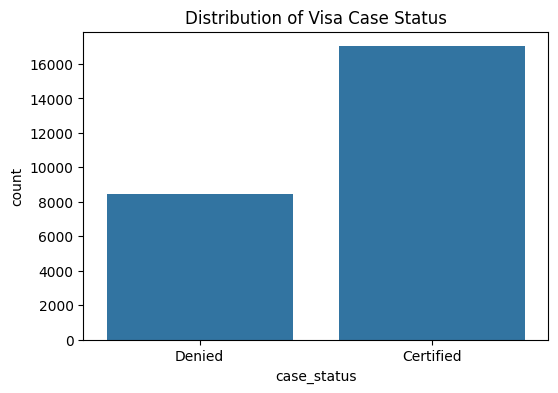

case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64


In [37]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='case_status')
plt.title('Distribution of Visa Case Status')
plt.show()

print(round(data['case_status'].value_counts(normalize=True)*100,2))

### Observations

- The majority of visa applications were **Certified (66.79%)**, while **33.21%** were Denied.
- Certified applications outnumber denied applications by approximately **2:1**.
- The target variable exhibits a **moderate class imbalance**, which may influence model performance.
- Accuracy alone may not be sufficient for evaluating classification models; therefore, metrics such as Precision, Recall, and F1-score will also be considered.
- To assess the impact of class imbalance, models will be developed using the original dataset, oversampled data (SMOTE), and undersampled data.

### Business Insight

- Historically, most visa applications in the dataset have been approved, indicating that certification is more common than denial.
- Understanding the factors that differentiate certified and denied applications can help EasyVisa prioritize cases and improve decision-making efficiency.

# Univariate Analysis

## Univariate Analysis of Categorical Variables

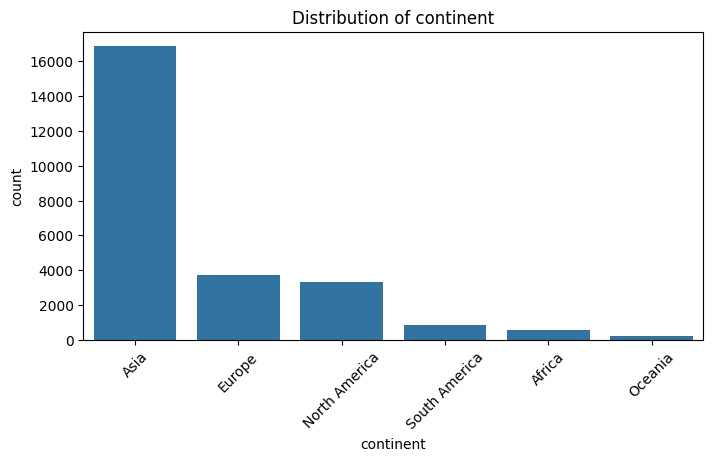

continent
Asia             66.17
Europe           14.65
North America    12.92
South America     3.34
Africa            2.16
Oceania           0.75
Name: proportion, dtype: float64
------------------------------------------------------------


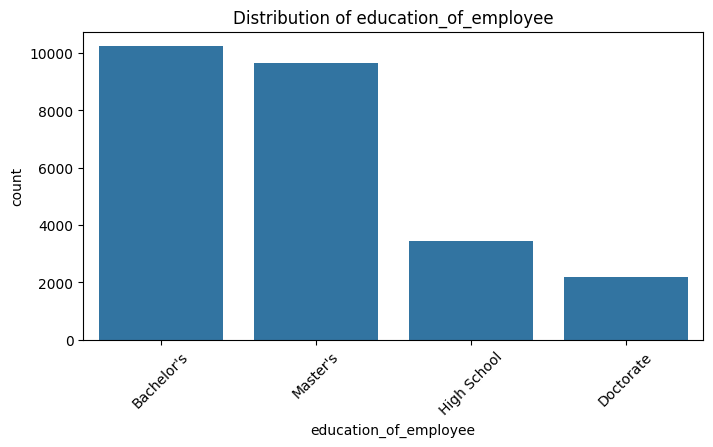

education_of_employee
Bachelor's     40.16
Master's       37.81
High School    13.42
Doctorate       8.60
Name: proportion, dtype: float64
------------------------------------------------------------


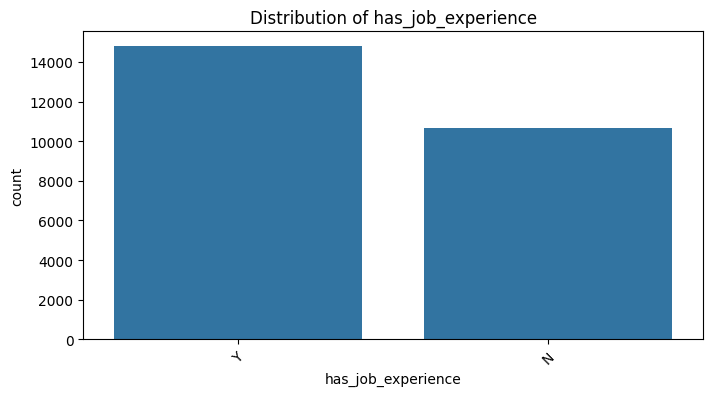

has_job_experience
Y    58.09
N    41.91
Name: proportion, dtype: float64
------------------------------------------------------------


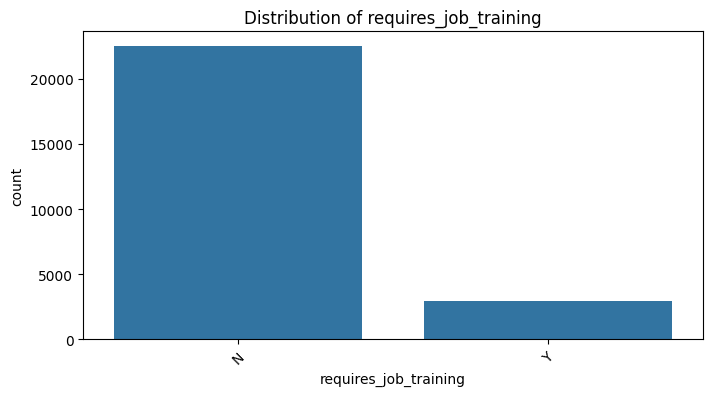

requires_job_training
N    88.4
Y    11.6
Name: proportion, dtype: float64
------------------------------------------------------------


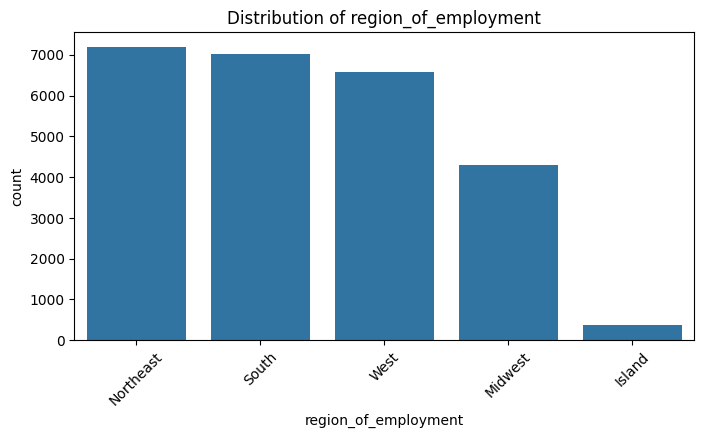

region_of_employment
Northeast    28.24
South        27.54
West         25.85
Midwest      16.90
Island        1.47
Name: proportion, dtype: float64
------------------------------------------------------------


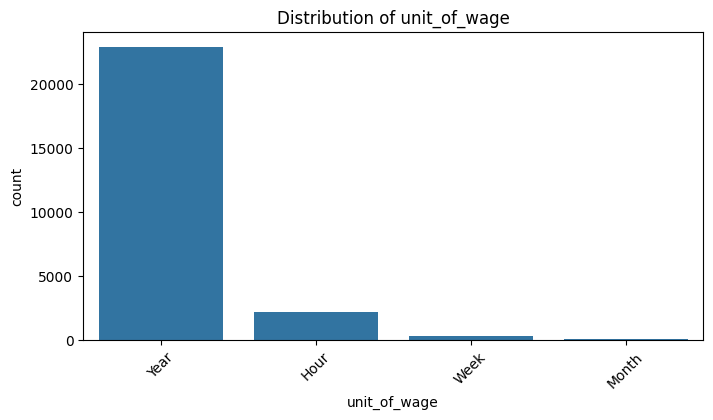

unit_of_wage
Year     90.12
Hour      8.47
Week      1.07
Month     0.35
Name: proportion, dtype: float64
------------------------------------------------------------


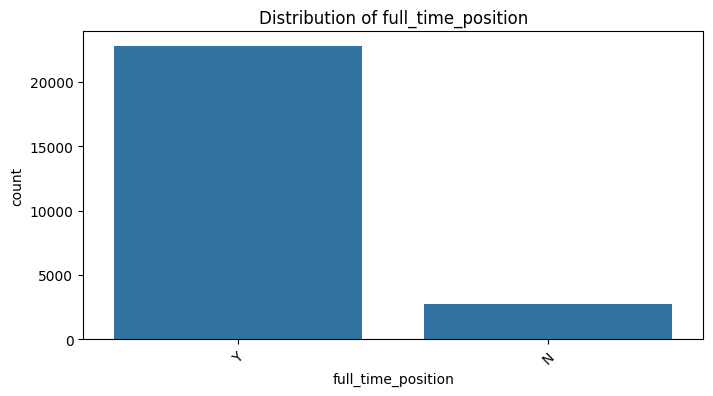

full_time_position
Y    89.38
N    10.62
Name: proportion, dtype: float64
------------------------------------------------------------


In [40]:
# List of categorical variables
categorical_cols = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'unit_of_wage',
    'full_time_position'
]

# Plot distribution of each categorical variable
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

    # Display percentage distribution
    print(data[col].value_counts(normalize=True).mul(100).round(2))
    print("-"*60)

## Observations - Categorical Variables

### Continent

- Applicants from **Asia** account for the majority of visa applications (**66.17%**), making it the most represented continent in the dataset.
- Europe (**14.65%**) and North America (**12.92%**) contribute a moderate share of applications.
- South America (**3.34%**), Africa (**2.16%**), and Oceania (**0.75%**) account for a relatively small proportion of applications.

### Education Level

- **Bachelor's degree holders** represent the largest applicant group (**40.16%**), closely followed by **Master's degree holders** (**37.81%**).
- Applicants with a **High School education** account for **13.42%** of applications.
- **Doctorate holders** represent the smallest education category (**8.60%**).
- More than three-quarters of applicants possess at least a Bachelor's degree, indicating a highly educated applicant pool.

### Job Experience

- A majority of applicants (**58.09%**) have prior job experience.
- Applicants without prior job experience account for **41.91%** of the dataset.
- This suggests that work experience may be an important factor influencing visa certification decisions.

### Job Training Requirement

- Most applicants (**88.40%**) do not require additional job training.
- Only **11.60%** of applicants require job training.
- This indicates that the majority of applicants are already considered job-ready.

### Region of Employment

- The **Northeast (28.24%)** has the highest concentration of visa applications.
- The **South (27.54%)** and **West (25.85%)** regions also account for a significant share of applications.
- The **Midwest (16.90%)** contributes a moderate number of applications.
- The **Island region (1.47%)** has the lowest number of applications.

### Unit of Wage

- Most positions (**90.12%**) report wages on a **yearly basis**.
- Hourly wages account for **8.47%** of applications.
- Weekly (**1.07%**) and monthly (**0.35%**) wage structures are relatively uncommon.
- The dominance of yearly wages suggests that most applications are associated with long-term employment opportunities.

### Full-Time Position

- The majority of applications (**89.38%**) are for **full-time positions**.
- Only **10.62%** of applications correspond to part-time positions.
- This indicates that foreign labor certifications are primarily sought for full-time employment.

## Key Insights

- The applicant pool is heavily concentrated in Asia and consists predominantly of highly educated individuals.
- Most applicants possess prior work experience and do not require additional job training.
- Visa applications are primarily associated with full-time positions offering yearly wages.
- The Northeast, South, and West regions account for the majority of employment opportunities.
- Several categorical variables exhibit highly imbalanced distributions, suggesting they may play an important role in explaining visa certification outcomes and should be explored further through bivariate analysis.

## Univariate Analysis of Numerical Variables

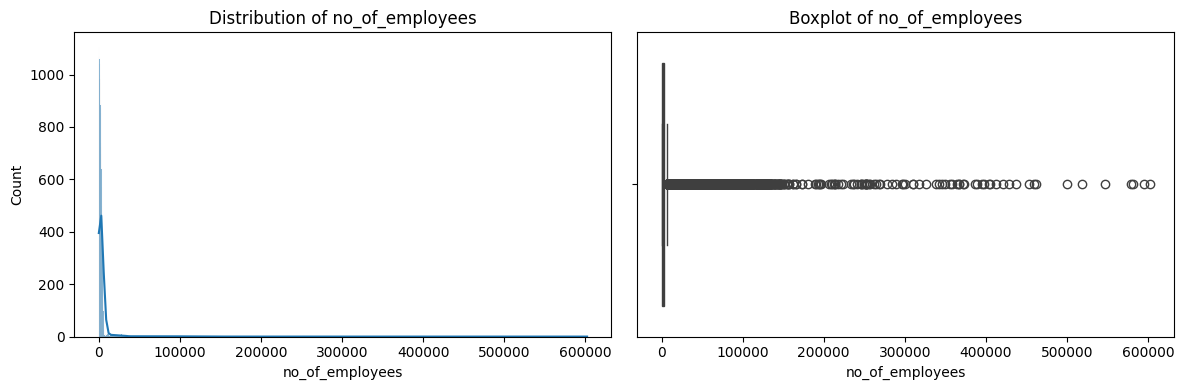

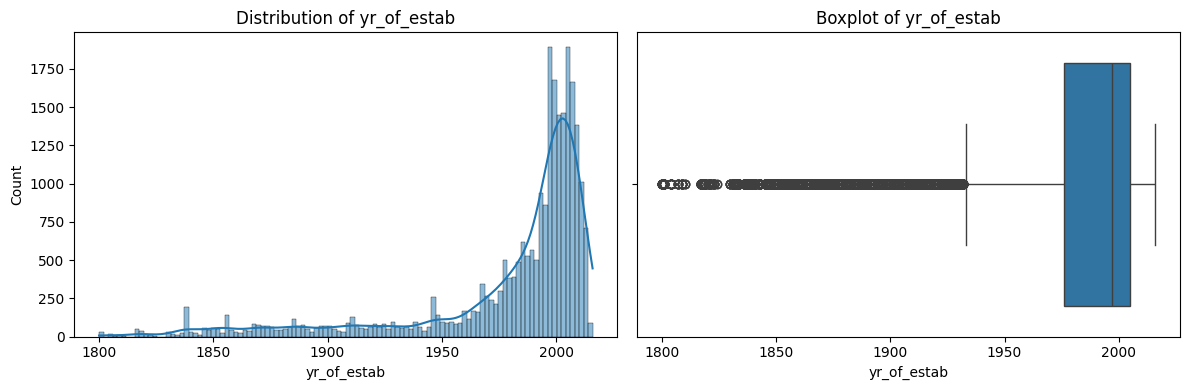

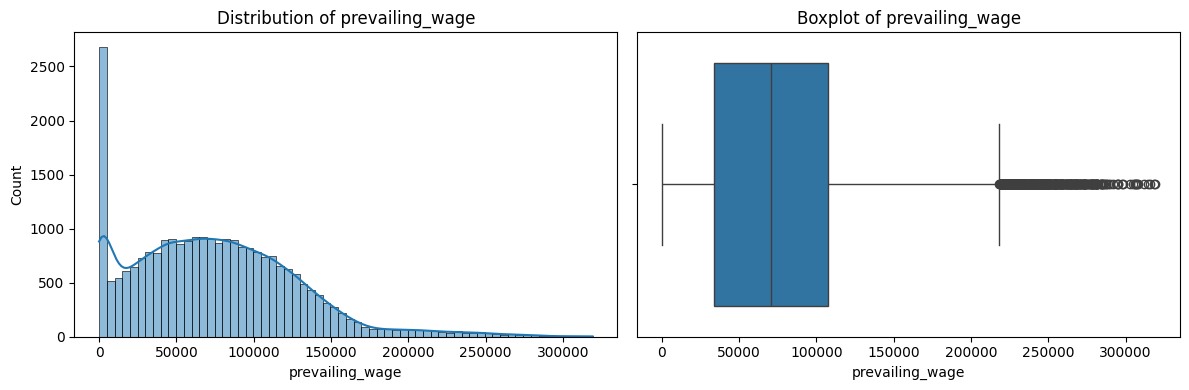

In [41]:
# Numerical variables
numerical_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in numerical_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution plot
    sns.histplot(data=data, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=data[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [42]:
# Skewness of numerical variables
data[['no_of_employees', 'yr_of_estab', 'prevailing_wage']].skew()

,0
no_of_employees,12.265273
yr_of_estab,-2.037301
prevailing_wage,0.755776


## Observations - Numerical Variables

### Number of Employees (no_of_employees)

- Most employers in the dataset have a relatively small workforce, while a few companies employ a very large number of employees.
- The distribution is heavily right-skewed, indicating that large employers are much less common than small and medium-sized employers.
- The boxplot shows several extreme values, suggesting the presence of outliers.
- These large values are likely to represent genuine company sizes rather than data errors and will be retained for further analysis.

### Year of Establishment (yr_of_estab)

- Most employers were established in recent decades, particularly after 1980.
- Only a small number of companies were founded before 1950.
- The distribution is left-skewed because older companies are relatively rare compared to newer organizations.
- The presence of both newly established and long-standing companies may provide useful insights into visa certification outcomes.

### Prevailing Wage (prevailing_wage)

- Prevailing wages vary considerably across applications.
- Most wages fall below $150,000, although a small number of positions offer significantly higher wages.
- The boxplot indicates the presence of some high-wage outliers.
- Wage levels may be an important factor influencing visa approval decisions and will be explored further in the bivariate analysis.

### Overall Insights

- Both no_of_employees and prevailing_wage contain a number of extreme values.
- These values appear to be valid observations rather than data quality issues.
- Since the models used in this project are primarily tree-based algorithms, outlier treatment is not expected to have a significant impact on model performance.
- Therefore, the outliers will be retained for further analysis and model building.

### Outlier Treatment

Boxplots identified outliers in both `no_of_employees` and `prevailing_wage`. However, these values appear to represent legitimate business observations rather than data quality issues. Since the primary models used in this project are tree-based algorithms, which are relatively robust to outliers, no outlier treatment was performed.

# Bivariate Analysis

In [43]:
# Continent vs visa certification status

continent_status = pd.crosstab(
    data["continent"],
    data["case_status"],
    normalize="index"
) * 100

continent_status

case_status,Certified,Denied
continent,,
Africa,72.050817,27.949183
Asia,65.310480,34.689520
Europe,79.233655,20.766345
North America,61.877278,38.122722
Oceania,63.541667,36.458333
South America,57.863850,42.136150


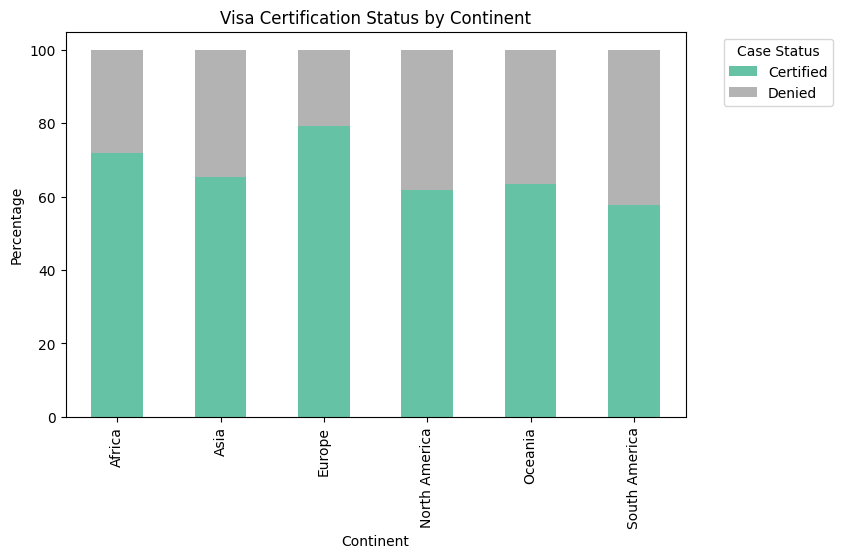

In [45]:
# Visualization of continent vs visa certification status

continent_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Continent")
plt.ylabel("Percentage")
plt.xlabel("Continent")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates differ noticeably across continents.
- **Europe** has the highest certification rate, with approximately **79.2%** of applications being certified and only **20.8%** denied.
- **Africa** also shows a relatively high certification rate of **72.1%**.
- Applicants from **Asia**, which represents the majority of applications in the dataset, have a certification rate of approximately **65.3%**.
- **North America** and **Oceania** show similar certification rates of around **62%–64%**.
- **South America** has the lowest certification rate (**57.9%**) and the highest denial rate (**42.1%**) among all continents.
- The difference between the highest certification rate (Europe: 79.2%) and the lowest certification rate (South America: 57.9%) is more than 21 percentage points, suggesting that continent may be an important factor associated with visa certification outcomes.

### Business Insight

- Applicants from Europe and Africa appear to have a higher likelihood of visa certification compared to applicants from other continents.
- Since Asia contributes the largest number of applications, even small changes in certification rates within this group could have a significant impact on overall visa approval volumes.
- The observed differences across continents suggest that geographic factors may influence certification outcomes and should be considered during model development.

In [46]:
# Education level vs visa certification status

education_status = pd.crosstab(
    data["education_of_employee"],
    data["case_status"],
    normalize="index"
) * 100

education_status.round(2)

case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.21,37.79
Doctorate,87.23,12.77
High School,34.04,65.96
Master's,78.63,21.37


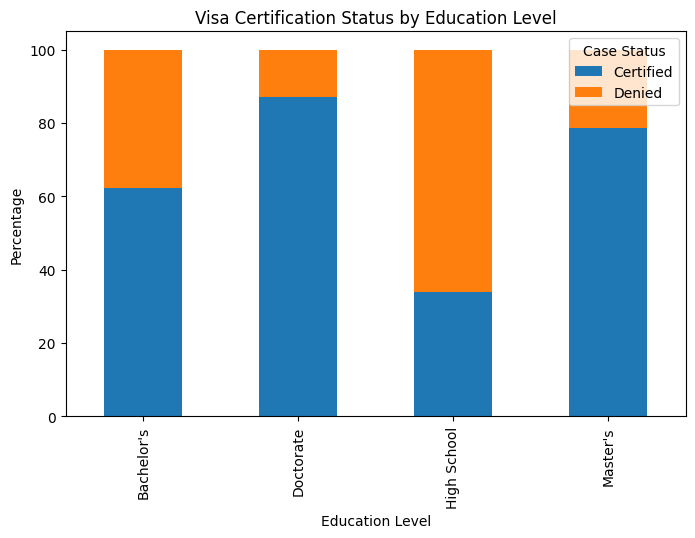

In [47]:
# Visualization of education level vs visa certification status

education_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Visa Certification Status by Education Level")
plt.ylabel("Percentage")
plt.xlabel("Education Level")
plt.legend(title="Case Status")
plt.show()

## Education Level vs Visa Certification Status

# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

# **Model Building - Original Data**

# **Model Building - Oversampled Data**

# **Model Building - Undersampled Data**

# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}
```


# **Model Comparison and Final Model Selection**

# **Actionable Insights and Recommendations**



*   



___